## Supervised Learning with Tensorflow and Deep Neural Networks
Mostly written by Olov Andersson. Some bits are borrowed from the official Tensorflow tutorials.

## Eager Execution
Since manually running your graph makes development difficult, with Tensorflow 2.0 they are moving towards an "eager execution" setting where the graph is constructed and executed automatically under the hood when you query it, allowing tensorflow code to work more like normal computation

In [1]:
from __future__ import absolute_import, division, print_function, unicode_literals
import tensorflow.compat.v1 as tf

tf.enable_eager_execution()

## Tensorflow to Train Machine Learning Models

In [3]:

# Build a toy dataset of 10 examples, 1D real-number input x
examples_x = tf.constant([2.02, 0.19, 2.9,  1.02, 0.35, 4.39, 0.15, 2.53, 3.07, 0.05])  # Using tf instead of numpy
print('Input examples x:', examples_x)

# ...and real-number output y
examples_y = tf.constant([27.07, 19.91, 26.18, 23.48, 19.22, 32.51, 20.11, 28.93, 28.29, 20.01])
print('Output examples y:', examples_y)

# Choose model as y = x*p1 + p0, linear regression where p1 is slope and p0 intercept
def model(inputs_x, parameters):  # Note that inputs_x is a vector (1D tensor) of x examples, and
  return inputs_x*parameters[1] + parameters[0]  # It returns a vector of corresponding y predictions

# Loss function for linear regression, given a choice parameters
def training_loss(parameters):
    # Calculate predicted output for examples with current parameters
    pred_y = model(examples_x, parameters)
    # With loss function as sum square difference against y examples
    return tf.reduce_sum(tf.square(examples_y-pred_y))  # Sum square loss

# Initialize parameters to 0 by creating a tf.Variable node
parameters = tf.Variable([0.0, 0.0])

Input examples x: tf.Tensor([2.02 0.19 2.9  1.02 0.35 4.39 0.15 2.53 3.07 0.05], shape=(10,), dtype=float32)
Output examples y: tf.Tensor([27.07 19.91 26.18 23.48 19.22 32.51 20.11 28.93 28.29 20.01], shape=(10,), dtype=float32)


Loss before training: 6234.28564
Loss after training: 248.048965
Parameters of linear model after training (intercept, slope): [12.2778835 5.68694258]


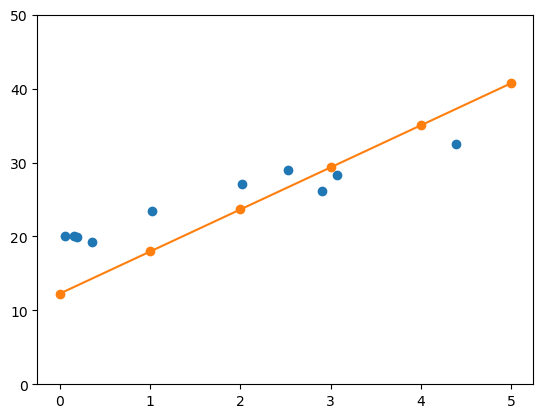

In [4]:
tf.print("Loss before training:", training_loss(parameters))

for i in range(10):  # Adjust number of iterations as desired
  # Compute loss and optimize parameters using gradient descent
  with tf.GradientTape() as tape:  # Records tensor operations so it can be used for later derivation (gradients)
    loss = training_loss(parameters)  # Defines tensorflow node 'loss' as a function of...

  gradient = tape.gradient(loss, parameters)  # QUESTION 1) Replace the question marks with the correct tensorflow nodes

  tf.assign(parameters, parameters - 0.01 * gradient)

tf.print("Loss after training:", training_loss(parameters))
tf.print("Parameters of linear model after training (intercept, slope):", parameters)

# Plotting
test_x = range(6) # Test inputs for x=0..6
test_y = model(test_x, parameters)  # Ask trained model for predictions
# Plot (NOTE: line comes from linear model assumption)
import matplotlib.pyplot as plt
_ = plt.plot(examples_x, examples_y, 'o', test_x, test_y, 'o-')
_ = plt.ylim([0,50])


To compute the gradient in the gradient descent learning code, we
compute the gradient of the loss (the node representing the sum of
squared errors) with respect to the parameters (the model’s intercept and slope), using 
```python
tape.gradient(loss, parameters)
```
in TensorFlow’s GradientTape. This allows the parameters to be updated
in a way that minimizes the loss.

## Train Neural Networks using Keras layers

Keras is a standard abstraction layer for deep learning that allows you define and train network models in a more compact form. It uses the same basic graph machinery as we just learned above, but spares us having to explicitly define each operation. Here we will illustrate how to use Keras to simplify neural network training.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Size of training set input tensor:  (60000, 28, 28)  outputs:  (60000,)


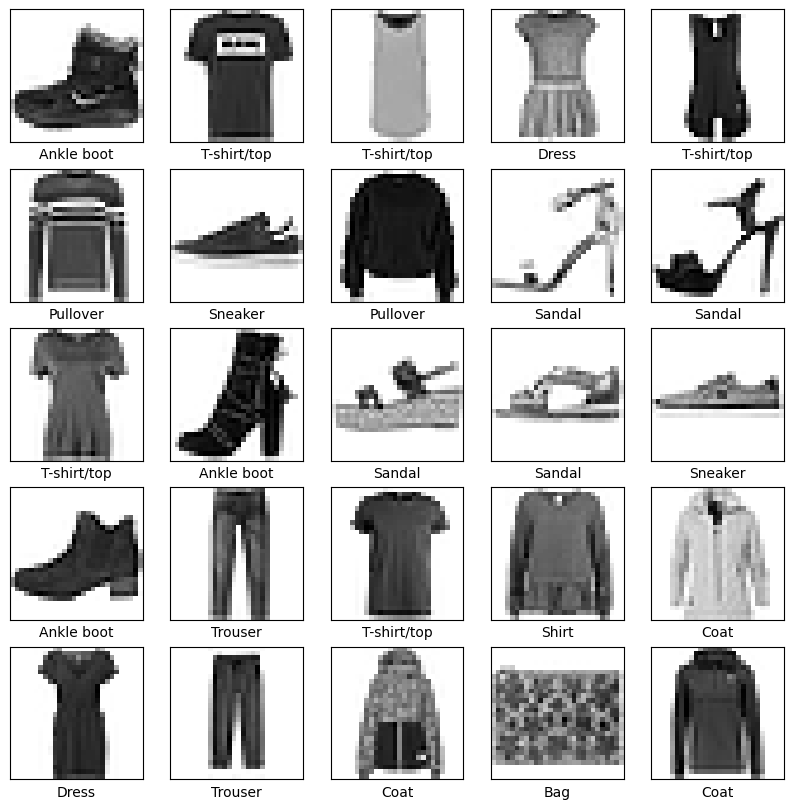

In [9]:
############### SETUP TF (IGNORE) #################
from __future__ import absolute_import, division, print_function, unicode_literals
import tensorflow.compat.v1 as tf
tf.enable_eager_execution()
from tensorflow import keras  # <-- Fix here
import numpy as np
import matplotlib.pyplot as plt

# Helper plot function
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

# Helper plot function
def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array[i], true_label[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')


############### LOAD DATA SETS #################
# Load images from: https://research.zalando.com/welcome/mission/research-projects/fashion-mnist/
# It is already split into training and test (validation) sets
fashion_mnist = keras.datasets.fashion_mnist  # <-- Fix here
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# The 9 output classes for the input images
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# It is good practice for NNs to input to 0..1 (here pixel intensity 0..255)
train_images = train_images / 255.0
test_images = test_images / 255.0

print("Size of training set input tensor: ", train_images.shape, " outputs: ", train_labels.shape)

# Display first 25 images and corresponding class label
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])


## Define Model and Loss Function (Resets All Parameters)

Keras is used to define a neural network with two hidden RelU layers, and soft-max output layer for 10 classes. The RelU is just a simplified sigmoid activation function, and soft-max is a generalization of the logistic function for when you have more than two labels. Neurons in these layers are standard fully-connected to the next layer, in Keras called "Dense" layers, with 128 neurons each.

In [12]:
# Define model using keras layer abstractions
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),  # Turn 28x28 image array into input vector X
    keras.layers.Dense(128, activation=tf.nn.relu),  # Dense = Fully connected layer w/ 128 neurons
    keras.layers.Dense(128, activation=tf.nn.relu),  # Dense = Fully connected layer w/ 128 neurons
    keras.layers.Dense(10, activation=tf.nn.softmax)  # Softmax is a sigmoid normalized for multiple classes
])


# Set loss function (like logistic regression but for multiple output classes),
# and type of stochastic gradient optimizer (ADAM).
model.compile(optimizer=keras.optimizers.Adam(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])  # Just for printing progress

# Reshape data for NN input layer (ignore)
train_images = np.squeeze(train_images)
test_images = np.squeeze(test_images)

# Print model information
model.summary()
print("Model and loss defined, parameters reset to small values.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

Model and loss defined, parameters reset to small values.


To compute the total number of parameters in the first `Dense` layer, we note the following:

- The input to the layer is a flattened vector from a 28 × 28 image, which gives us 28 × 28 = 784 input features.
- The first `Dense` layer has 128 neurons, and each neuron has a weight for each input feature, plus one bias term.

So, for each neuron, the number of parameters is:


Parameters per neuron = 784 (weights) + 1 (bias) = 785


Since there are 128 neurons in the first dense layer, the total number of parameters is:

Total parameters = 785 × 128 = 100480

## Train Model in Tensorflow (run several times to train more)

6000/6000 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.7904 - loss: 0.5859
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 591us/step - accuracy: 0.8596 - loss: 0.3903
Test accuracy: 0.8536999821662903
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 913us/step


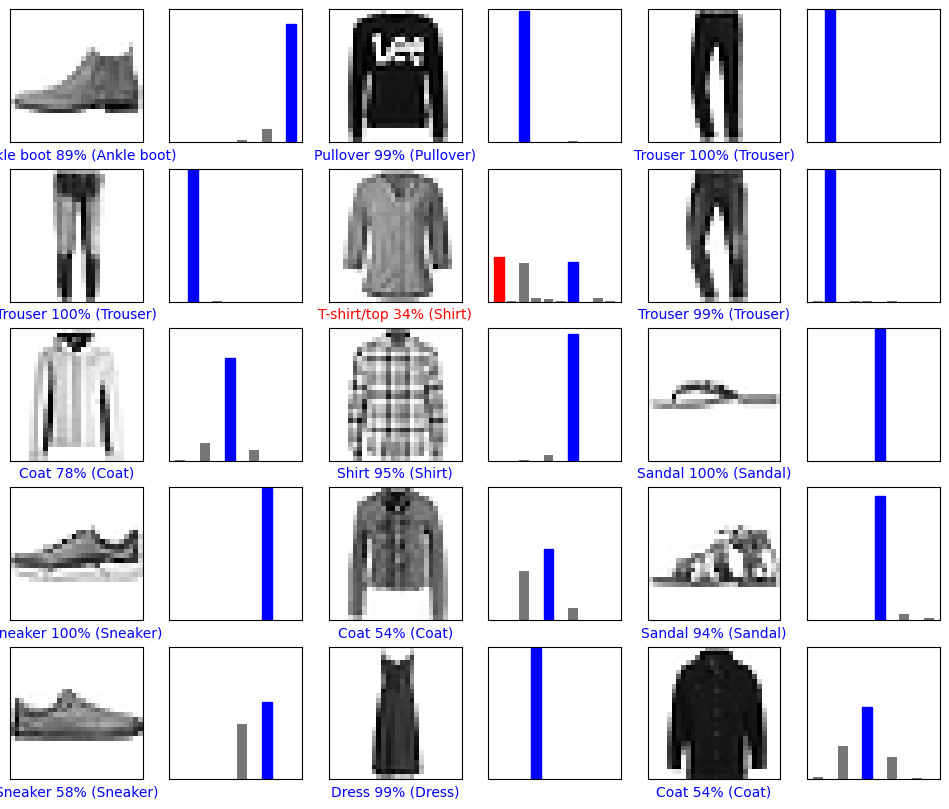

In [21]:
# Train model using Tensorflow
model.fit(train_images, train_labels, epochs=1, batch_size=10)

# Compute accuracy (% correctly classified) on test/validation set
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Test accuracy:', test_acc)

# Manually make predictions to visually inspect predictions on test set
predictions = model.predict(test_images)
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
# Plot the first X test images, their predicted label, and the true label
# Color correct predictions in blue, incorrect predictions in red
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions, test_labels, np.squeeze(test_images))
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions, test_labels)

## Mini-batch sizes

In this experiment, we evaluated how different mini-batch sizes affect the training time and accuracy of a neural network. We trained the network using batch sizes of 1, 10, 100, 1000, and 60000, recording the training time and accuracy for each run. After each training, the parameters were reset to ensure consistency across batch sizes. The training time and accuracy for each batch size were saved and later plotted to visualize the trade-offs as shown below.

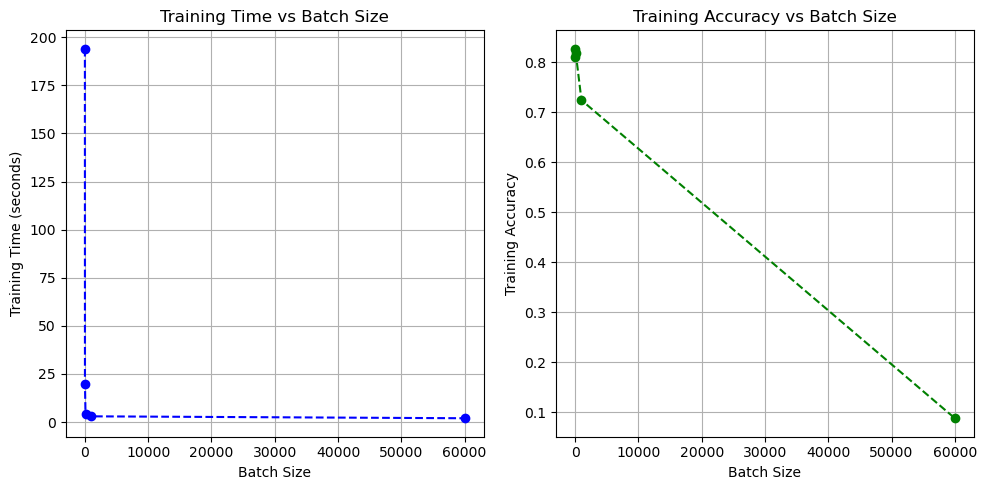

In [20]:
import matplotlib.pyplot as plt

# Batch sizes and extracted data
batch_sizes = [1, 10, 100, 1000, 60000]
training_times = [194, 20, 4, 3, 2]
training_accuracies = [0.8114, 0.8271, 0.8186, 0.7243, 0.0875]

# Create the figure
plt.figure(figsize=(10, 5))

# Plot 1: Training Time vs Batch Size
plt.subplot(1, 2, 1)
plt.plot(batch_sizes, training_times, marker='o', linestyle='--', color='b')
plt.xlabel('Batch Size')
plt.ylabel('Training Time (seconds)')
plt.title('Training Time vs Batch Size')
plt.grid(True)

# Plot 2: Training Accuracy vs Batch Size
plt.subplot(1, 2, 2)
plt.plot(batch_sizes, training_accuracies, marker='o', linestyle='--', color='g')
plt.xlabel('Batch Size')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy vs Batch Size')
plt.grid(True)

plt.tight_layout()

plt.savefig("training_time_accuracy_vs_batch_size.pdf")

plt.show()


 The results showed that smaller batch sizes (1, 10, and 100) took longer to train but generally yielded higher accuracy while larger batch sizes (1000 and 60000) trained faster but resulted in lower accuracy. In this specific case, a batch size of 10 produced the highest accuracy (82.71%) with a reasonable training time of 20 seconds which shows that for this dataset and model, a batch size of 10 provides a good balance between accuracy and training efficiency.

## Convolutional Neural Network (Better for Images)

In [29]:
# Define CNN model
model = keras.Sequential([
    keras.layers.Conv2D(filters=128, kernel_size=8, padding='same', activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Conv2D(filters=64, kernel_size=4, padding='same', activation='relu'),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# Set loss function (like logistic regression but for multiple output classes),
# and type of stochastic gradient optimizer (ADAM).
model.compile(optimizer=keras.optimizers.Adam(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Reshape input data for the CNN, from (28, 28) to (28, 28, 1)
w, h = 28, 28
train_images = train_images.reshape(train_images.shape[0], w, h, 1)
test_images = test_images.reshape(test_images.shape[0], w, h, 1)

# Print model information
model.summary()
print("Model and loss defined, parameters reset to small values.")

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_23 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 16)             │        50,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,818 (741.48 KB)

 Trainable params: 189,818 (741.48 KB)

 Non-trainable params: 0 (0.00 B)

Model and loss defined, parameters reset to small values.


12000/12000 ━━━━━━━━━━━━━━━━━━━━ 223s 19ms/step - accuracy: 0.8685 - loss: 0.3583
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8819 - loss: 0.3303
Test accuracy: 0.883400022983551
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


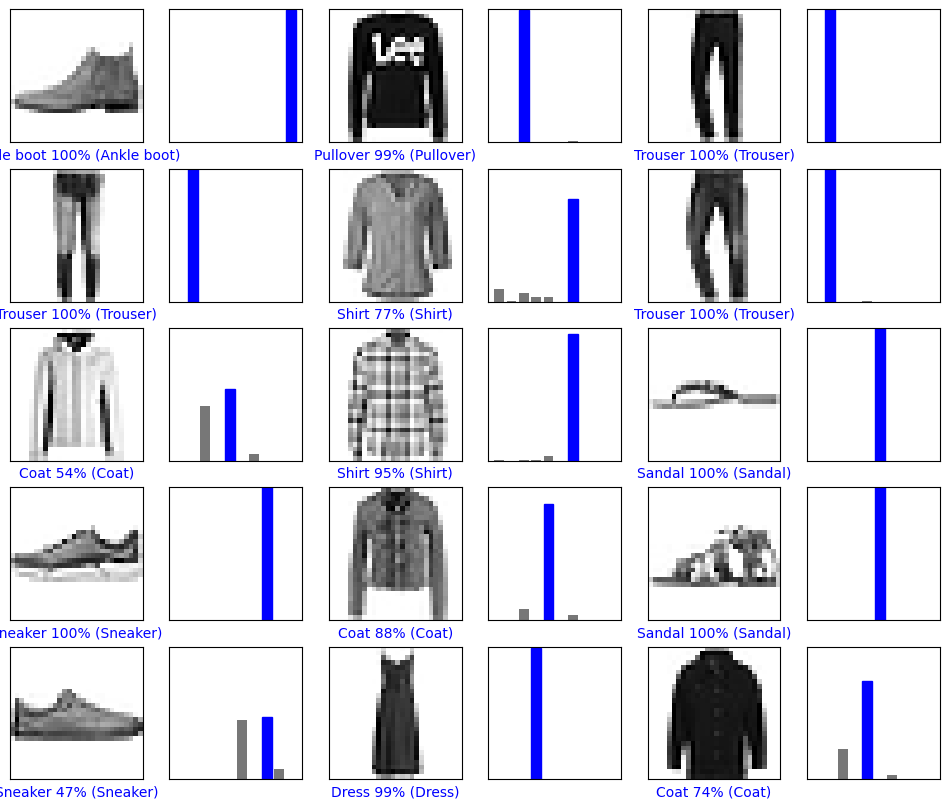

In [31]:
# Train model using Tensorflow
model.fit(train_images, train_labels, epochs=1, batch_size=5)

# Compute accuracy (% correctly classified) on test/validation set
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Test accuracy:', test_acc)

# Manually make predictions to visually inspect predictions on test set
predictions = model.predict(test_images)
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
# Plot the first X test images, their predicted label, and the true label
# Color correct predictions in blue, incorrect predictions in red
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions, test_labels, np.squeeze(test_images))
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions, test_labels)